In [503]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [508]:
class Value:
    def __init__(self,data, _children = (), _op =() , label = "") -> None:
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self) -> str:
        return f"Value(data={self.data})"
    def __add__(self, other) -> "Value":
        out = Value(self.data + other.data, (self, other), '+')
        def _backward() -> None:
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __mul__(self, other) -> "Value":
        out = Value(self.data * other.data, (self,other), '*')
        def _backward() ->None:
            self.grad = other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def tanh(self) -> Value: 
        x = self.data
        tanh = (math.exp(2*x) - 1) /(math.exp(2*x) + 1)
        out = Value(tanh, (self, ), 'tanh')
        def _backward() -> None:
            self.grad += (1 - out.data ** 2) * out.grad
        out._backward = _backward
        return out
    def backward(self) -> None:

        visited = set()
        topo = []
        def topo_sort(node) -> None:
            if node in visited:
                return
            visited.add(node)
            for child in node._prev:
                topo_sort(child)
            topo.append(node)
        topo_sort(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [510]:
from graphviz import Digraph


def trace(root):# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:
    # build node and edges graph
    nodes, edges = set(), set()
    def build(v) -> None:
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot  = Digraph(format= 'svg', graph_attr={'rankdir': 'LR'}) #LR is Left to Right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in graph create a rectangular node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f  }" % (n.label, n.data, n.grad),shape='record')
        if n._op:
            # if it is from another operation create a operation node for it 
            dot.node(name = uid + n._op, label = n._op)
            #and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot



In [513]:
#inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias b
b = Value(6.8813735870195432, label='b')
#x1*w1 and x2*w2
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
#compute x1*w1 + x2*w2 
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label= 'x1*w1 + x2*w2'
#compute (x1* w1 + x2*w2) + b
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

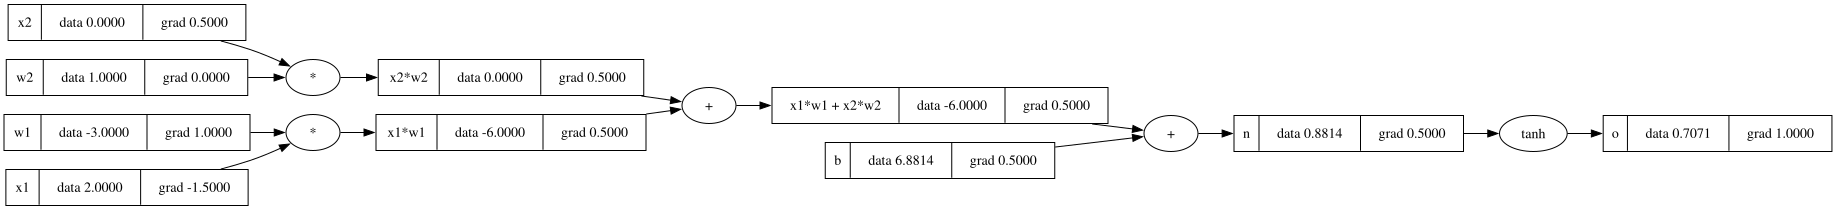

In [514]:
draw_dot(o)

In [515]:
o.backward()